## 1. Linear Relationship 
 ### The input column should have some sort of linear relationship with the output column.
  
 Positve correlated data:- This means if the value of the x increase then the value of y must also increase respectively. This is called positve Correlated data.

 
 Negative correlated data :- This means if the value of the x increases then the value of y should decrease respectively and vice versa.

 Polynomial Correlated data  :- this means that if x increase or decreases then the value of y will also increase/decrease with some power.

 x: 1 y:2.8
 x: 2 y:3.72
 x: 3 y:5.97
 x: 4 y:8.37
 x: 5 y:9.97
 x: 6 y:13.13
 x: 7 y:14.38
 x: 8 y:16.66
 x: 9 y:19.18
 x: 10 y:20.98
 x: 11 y:23.78
 x: 12 y:25.09
 x: 13 y:26.37
 x: 14 y:28.91
 x: 15 y:29.79
 x: 16 y:30.7
 x: 17 y:35.36
 x: 18 y:37.81
 x: 19 y:38.08
 x: 20 y:41.17


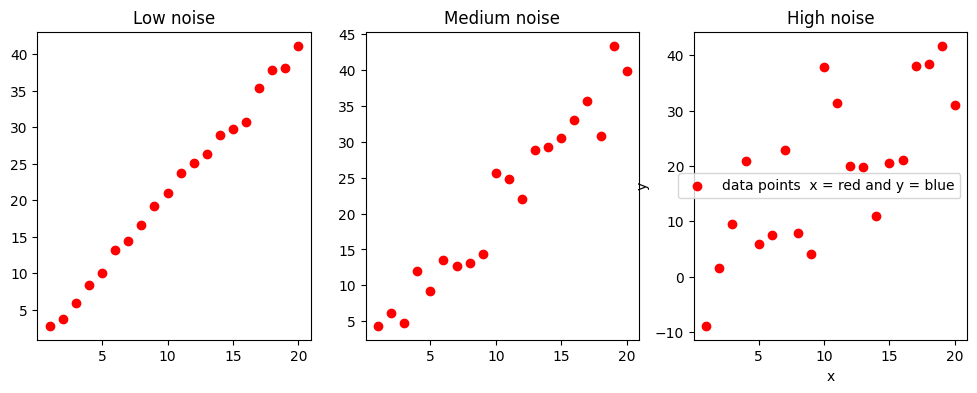

In [35]:
import numpy as np 
import matplotlib.pyplot as plt

x = np.arange(1,21)



y = 2*x + 1 + np.random.randn(len(x))*1
y2 = 2*x + 1 + np.random.randn(len(x))*3
y3 = 2*x + 1 + np.random.randn(len(x))*10

for i in range(len(x)):
    print(f" x: {x[i]} y:{round(float(y[i]),2)}")

plt.figure(figsize = (12,4))

plt.subplot(1,3,1)
plt.scatter(x,y, c = ['red'])
plt.title("Low noise")

plt.subplot(1,3,2)
plt.scatter(x,y2, c = ['red'])
plt.title("Medium noise")

plt.subplot(1,3,3)
plt.scatter(x,y3, c = ['red'])
plt.title("High noise")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(["data points  x = red and y = blue"])
plt.show()


###  Here we can see the first graph shows positive correlation between the points 

the graph 3 it is hard to fit a line in this a polynomial regression appraoch might work 

the 2 graph is a normal graph and can be solved easily using linear regression 

# 2. Multicollinearity 

    if you data feature/dimensions (not the target variable/class) have correlation between them. 

    To detect whether your data has multicollinaerity.
     1. import the variance_inflation_factor from the statsmodels.stats.outliers_influence
     2. if the value of output is near 1 then your data has no multicollinearity and if the value is near or more than 5 then your data has high multicollinearity 
 ### Your data must not have multicolinearity 

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [37]:
df = pd.read_csv("concrete_data.csv")
df.head(5)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [38]:
vif = []

for i in range(len(df.columns)-1):
    vif.append(variance_inflation_factor(df.values,i))

vif_df = pd.DataFrame(vif, index = df.columns[:-1], columns = ["VIF"])

vif_df

,VIF
Cement,26.232325
Blast Furnace Slag,4.442518
Fly Ash,4.560002
Water,92.504056
Superplasticizer,5.519535
Coarse Aggregate,85.896630
Fine Aggregate,73.514995
Age,2.434942


| Feature            | VIF   | Interpretation              |
| ------------------ | ----- | --------------------------- |
| Cement             | 26.23 | 🔴 Severe multicollinearity |
| Blast Furnace Slag | 4.44  | 🟡 Moderate                 |
| Fly Ash            | 4.56  | 🟡 Moderate                 |
| Water              | 92.50 | 🔴 Extremely high           |
| Superplasticizer   | 5.52  | 🟠 Borderline high          |
| Coarse Aggregate   | 85.90 | 🔴 Extremely high           |
| Fine Aggregate     | 73.51 | 🔴 Extremely high           |
| Age                | 2.43  | 🟢 Safe                     |



now to remove this we can in coporate various methods such as PCA ridge-regression lasso regression 

# Normal Residual 

### A normal residual means:

The error terms (residuals) of the model follow a normal (Gaussian) distribution.

### What are residuals?

Residual = actual value − predicted value

They represent the unexplained part of your model.

### What “normal residuals” imply

If residuals are normal:

1. Errors are symmetrically distributed
2. Most errors are small
3. Large errors are rare
4. Distribution looks like a bell curve

### How it looks visually
1. Histogram → bell-shaped
2. Q-Q plot → points lie on a straight line

### If residuals are NOT normal

You may see:

1. Skewed distribution
2. Heavy tails
3. Outliers

Consequences:

1. Coefficient estimates still work (OLS is unbiased)
2. But inference becomes unreliable


We can use histograms, KDE plot to spot the distribution of data

In [40]:
y = df["Strength"].values
x =df.drop("Strength",axis =1).values

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)
x_train.shape, x_test.shape

((824, 8), (206, 8))

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model = LinearRegression()

model.fit(x_train,y_train)

y_pred = model.predict(x_test)

print("R2 Score: ",r2_score(y_test,y_pred))



R2 Score:  0.627553179231485


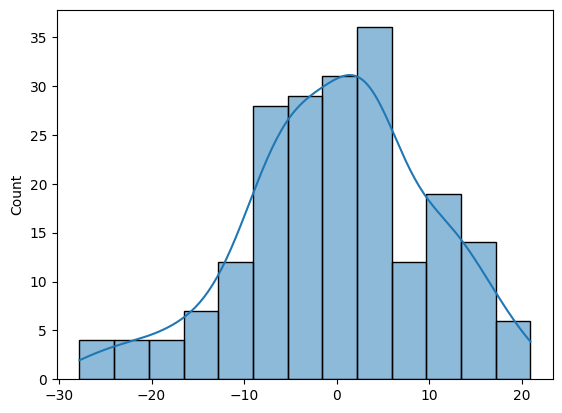

In [44]:
residuals = y_test - y_pred
import seaborn as sns

sns.histplot(residuals, kde = True)
# plt.scatter(y_pred,residuals, c = ['red'])
# plt.axhline(y=0, color='blue', linestyle='--')
# plt.xlabel("predicted values")
# plt.ylabel("residuals")
# plt.title("residual Plot")
plt.show()

### As you can see the data a little bit of right skewwd but that is fine and can be worked with
